<a href="https://colab.research.google.com/github/Radiation444/CollegeUtility/blob/main/OpenAI_CLIP_for_SWE_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is a very basic use of OpenAI CLIP where we are classifying images of objects.
We plan to integrate this with our app and add a embedding feature that extracts information from images and/or text using CLIP, and then compares the final embeddings to find a match in the database using hashing.
The embeddings will represent information like item type, color, location lost/found, etc.

The runtimes are also satisfactory.

Further tests will include testing the time require to fetch embeddings from database and query new embeddings over the database. We are considering options like FastAPI to connect the model to the database.

**The images are taken from the IITJ Security mails.**

In [ ]:
!pip install -U transformers
!pip install --yes -c pytorch pytorch=1.7.1 torchvision cudatoolkit=11.0
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 103.4 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0

Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: --yes
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.5 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-gfp1rhcu
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-gfp1rhcu
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) .

Model loading time: 3.8080 seconds
Text tokenization time: 0.0007 seconds
Text features encoding time: 0.0225 seconds


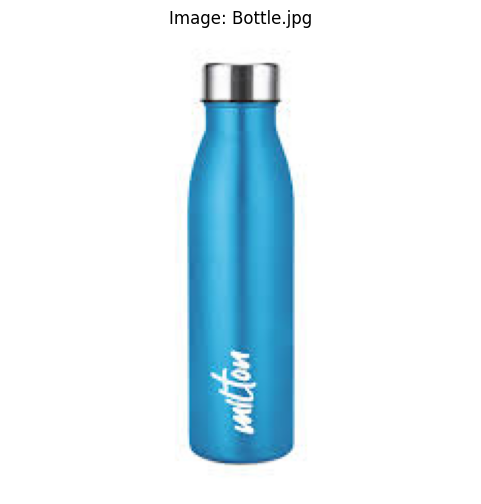

Label probabilities for Bottle.jpg:
  keys: 0.0011
  bottle: 0.9966
  watch: 0.0004
  earbuds: 0.0019

------------------------------



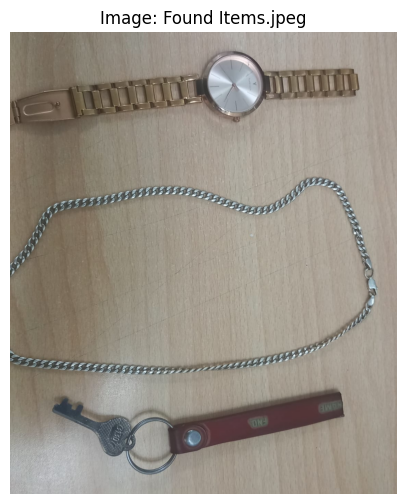

Label probabilities for Found Items.jpeg:
  keys: 0.0384
  bottle: 0.0018
  watch: 0.9590
  earbuds: 0.0007

------------------------------



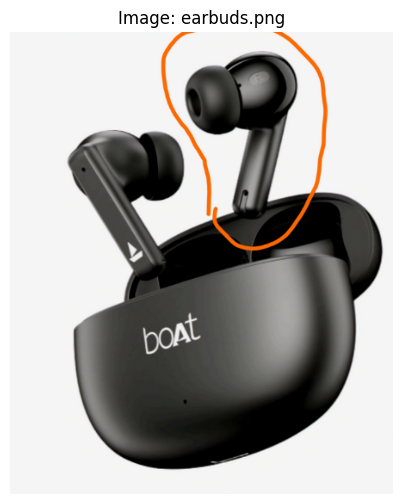

Label probabilities for earbuds.png:
  keys: 0.0038
  bottle: 0.0011
  watch: 0.0136
  earbuds: 0.9814

------------------------------



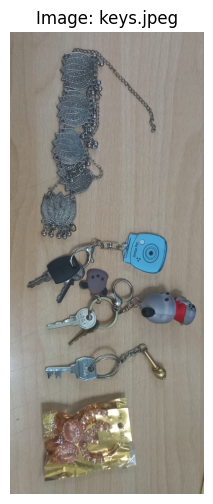

Label probabilities for keys.jpeg:
  keys: 0.9976
  bottle: 0.0002
  watch: 0.0015
  earbuds: 0.0004

------------------------------



In [ ]:
import torch
import clip
from PIL import Image
import matplotlib.pyplot as plt
import time

device = "cuda" if torch.cuda.is_available() else "cpu"

start_time = time.time()
model, preprocess = clip.load("ViT-B/32", device=device)
model_load_time = time.time() - start_time
print(f"Model loading time: {model_load_time:.4f} seconds")

image_paths = [
    "Bottle.jpg",
    "Found Items.jpeg",
    "earbuds.png",
    "keys.jpeg"
]

preprocessed_images = []
image_preprocess_times = [] # To store preprocessing time for each image

for path in image_paths:
    start_time = time.time()
    img = Image.open(path)
    preprocessed_img_tensor = preprocess(img).unsqueeze(0).to(device)
    preprocess_time = time.time() - start_time
    image_preprocess_times.append(preprocess_time) # Store individual preprocess time

    preprocessed_images.append(preprocessed_img_tensor)

text_labels = ["keys", "bottle", "watch", "earbuds"]

# Time text tokenization
start_time = time.time()
text = clip.tokenize(text_labels).to(device)
tokenize_text_time = time.time() - start_time
print(f"Text tokenization time: {tokenize_text_time:.4f} seconds")

# Store inference times per image
image_inference_data = [] # List of dictionaries for each image

# Encode text features once (since text is constant)
start_time = time.time()
text_features = model.encode_text(text)
encode_text_features_time = time.time() - start_time
print(f"Text features encoding time: {encode_text_features_time:.4f} seconds")


for i, image_tensor in enumerate(preprocessed_images):
    # Display the original image
    original_image = Image.open(image_paths[i])
    plt.figure(figsize=(6, 6))
    plt.imshow(original_image)
    plt.title(f"Image: {image_paths[i].split('/')[-1]}")
    plt.axis('off')
    plt.show()

    current_image_data = {'image_name': image_paths[i].split('/')[-1]}
    current_image_data['preprocess_time'] = image_preprocess_times[i] # Retrieve stored preprocess time

    with torch.no_grad():
        # Time image feature encoding
        start_time = time.time()
        image_features = model.encode_image(image_tensor)
        encode_image_time = time.time() - start_time
        current_image_data['encode_image_time'] = encode_image_time

        # Time logits calculation
        start_time = time.time()
        logits_per_image, _ = model(image_tensor, text)
        logits_time = time.time() - start_time
        current_image_data['logits_time'] = logits_time

        probs = logits_per_image.softmax(dim=-1).cpu().numpy().flatten()

    image_inference_data.append(current_image_data)

    print(f"Label probabilities for {image_paths[i].split('/')[-1]}:")
    for label, prob in zip(text_labels, probs):
        print(f"  {label}: {prob:.4f}")
    print("\n" + "-"*30 + "\n")

# Store all timing data for plotting in a dictionary that will be accessible in the kernel
all_runtimes = {
    'model_load_time': model_load_time,
    'tokenize_text_time': tokenize_text_time,
    'encode_text_features_time': encode_text_features_time,
    'image_inference_data': image_inference_data
}

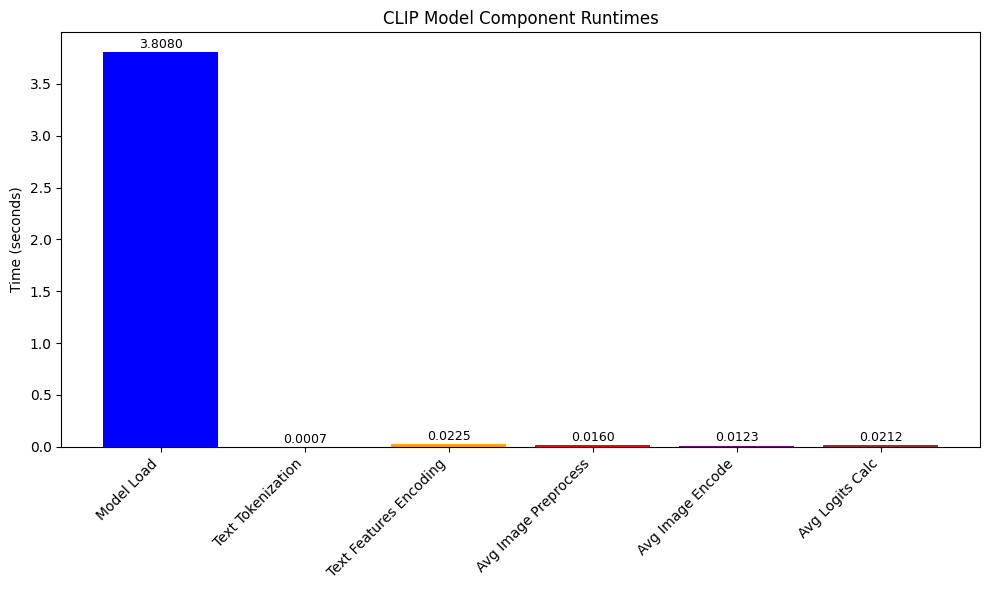

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract global runtimes
model_load_time = all_runtimes['model_load_time']
tokenize_text_time = all_runtimes['tokenize_text_time']
encode_text_features_time = all_runtimes['encode_text_features_time']

# Calculate average image-specific runtimes
num_images = len(all_runtimes['image_inference_data'])

if num_images > 0:
    avg_preprocess_time = np.mean([data['preprocess_time'] for data in all_runtimes['image_inference_data']])
    avg_encode_image_time = np.mean([data['encode_image_time'] for data in all_runtimes['image_inference_data']])
    avg_logits_time = np.mean([data['logits_time'] for data in all_runtimes['image_inference_data']])
else:
    avg_preprocess_time = 0
    avg_encode_image_time = 0
    avg_logits_time = 0

# Prepare data for plotting
labels = [
    'Model Load',
    'Text Tokenization',
    'Text Features Encoding',
    'Avg Image Preprocess',
    'Avg Image Encode',
    'Avg Logits Calc'
]

times = [
    model_load_time,
    tokenize_text_time,
    encode_text_features_time,
    avg_preprocess_time,
    avg_encode_image_time,
    avg_logits_time
]

# Create the bar chart
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(labels, times, color=['blue', 'green', 'orange', 'red', 'purple', 'brown'])

ax.set_ylabel('Time (seconds)')
ax.set_title('CLIP Model Component Runtimes')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping

# Add actual time values on top of bars for clarity
for i, v in enumerate(times):
    ax.text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.show()

In the second image, we can see that issues may when there are multiple objects in one image, we are considering possible solutions like allowing only one object at a time.